# Computer Resource Profile Wrapper Function 

In our `CResourceProfiler.py` we provide a wrapper function which is a `profile` decorator to quantify a function’s resource use for experiments and demos. It records CPU time for each call and, if desired, captures post-call memory snapshots (RSS/VMS) so you can compare workloads, track trends, and report results. It supports three usage modes: print a one-line summary, store CPU times in a list, or store CPU time plus memory in a dictionary for later analysis and plotting. The goal is to standardize measurement across functions so you can fairly compare performance and document resource footprints.

### Use Cases:

* @profile() (no args) → wraps the function; if print_line=False and store=None, it will not output anything (you’d usually combine with 1–3).
  
* @profile(print_line=True) → prints a one-line summary after each call.

* @profile(store=my_list) → appends CPU time (seconds) to my_list.

* @profile(store=my_dict) where my_dict is a dict → appends to my_dict["cpu_time"], ["rss"], ["vms"].


**Note:** CPU time excludes sleep; it measures actual CPU used by your process. Also, <span style="color: yellow">for memory computation `psutil` was used, so make sure it is installed in your environmnent.</span>

## Usage Example

Suppose we have three functions we want to profile

In [16]:
import numpy as np
from CResourceProfiler import profile


@profile(print_line=True)
def f_fast(n=10_000):
    a = np.arange(n, dtype=np.float64)
    return float(a.sum())

@profile(print_line=True)
def f_medium(n=400):
    A = np.random.rand(n, n)
    B = np.random.rand(n, n)
    return float((A @ B).sum())

@profile(print_line=True)
def f_slow(n=700):
    A = np.random.rand(n, n)
    B = np.random.rand(n, n)
    return float((A @ B).sum())

f_fast()
f_medium()
f_slow()

[PROFILE] __main__.f_fast() -> CPU Time 0.00035 s  | RSS: 43.48 MB | VMS: 402050.77 MB
[PROFILE] __main__.f_medium() -> CPU Time 0.00435 s  | RSS: 49.12 MB | VMS: 402050.77 MB
[PROFILE] __main__.f_slow() -> CPU Time 0.00697 s  | RSS: 60.72 MB | VMS: 402050.77 MB


/var/folders/tr/7wkvpsfn21zd7c6xmmpt7nfm0000gr/T/ipykernel_1746/1616926818.py:14: RuntimeWarning: divide by zero encountered in matmul
  return float((A @ B).sum())
/var/folders/tr/7wkvpsfn21zd7c6xmmpt7nfm0000gr/T/ipykernel_1746/1616926818.py:14: RuntimeWarning: overflow encountered in matmul
  return float((A @ B).sum())
/var/folders/tr/7wkvpsfn21zd7c6xmmpt7nfm0000gr/T/ipykernel_1746/1616926818.py:14: RuntimeWarning: invalid value encountered in matmul
  return float((A @ B).sum())
/var/folders/tr/7wkvpsfn21zd7c6xmmpt7nfm0000gr/T/ipykernel_1746/1616926818.py:20: RuntimeWarning: divide by zero encountered in matmul
  return float((A @ B).sum())
/var/folders/tr/7wkvpsfn21zd7c6xmmpt7nfm0000gr/T/ipykernel_1746/1616926818.py:20: RuntimeWarning: overflow encountered in matmul
  return float((A @ B).sum())
/var/folders/tr/7wkvpsfn21zd7c6xmmpt7nfm0000gr/T/ipykernel_1746/1616926818.py:20: RuntimeWarning: invalid value encountered in matmul
  return float((A @ B).sum())


85694448.8606915

### Now let's store CPU time using list

[PROFILE] __main__.f_fast() -> CPU Time 0.00081 s  | RSS: 64.36 MB | VMS: 402050.77 MB
[PROFILE] __main__.f_medium() -> CPU Time 0.00533 s  | RSS: 66.94 MB | VMS: 402050.77 MB
[PROFILE] __main__.f_slow() -> CPU Time 0.00950 s  | RSS: 70.70 MB | VMS: 402050.77 MB
[PROFILE] __main__.f_fast() -> CPU Time 0.00008 s  | RSS: 70.70 MB | VMS: 402050.77 MB
[PROFILE] __main__.f_medium() -> CPU Time 0.00247 s  | RSS: 72.03 MB | VMS: 402050.77 MB
[PROFILE] __main__.f_slow() -> CPU Time 0.00615 s  | RSS: 72.12 MB | VMS: 402050.77 MB
[PROFILE] __main__.f_fast() -> CPU Time 0.00007 s  | RSS: 72.12 MB | VMS: 402050.77 MB
[PROFILE] __main__.f_medium() -> CPU Time 0.00154 s  | RSS: 73.33 MB | VMS: 402050.77 MB
[PROFILE] __main__.f_slow() -> CPU Time 0.00587 s  | RSS: 79.62 MB | VMS: 402050.77 MB
[PROFILE] __main__.f_fast() -> CPU Time 0.00006 s  | RSS: 79.62 MB | VMS: 402050.77 MB
[PROFILE] __main__.f_medium() -> CPU Time 0.00140 s  | RSS: 80.89 MB | VMS: 402050.77 MB
[PROFILE] __main__.f_slow() -> CPU 

/var/folders/tr/7wkvpsfn21zd7c6xmmpt7nfm0000gr/T/ipykernel_1746/1616926818.py:14: RuntimeWarning: divide by zero encountered in matmul
  return float((A @ B).sum())
/var/folders/tr/7wkvpsfn21zd7c6xmmpt7nfm0000gr/T/ipykernel_1746/1616926818.py:14: RuntimeWarning: overflow encountered in matmul
  return float((A @ B).sum())
/var/folders/tr/7wkvpsfn21zd7c6xmmpt7nfm0000gr/T/ipykernel_1746/1616926818.py:14: RuntimeWarning: invalid value encountered in matmul
  return float((A @ B).sum())
/var/folders/tr/7wkvpsfn21zd7c6xmmpt7nfm0000gr/T/ipykernel_1746/1616926818.py:20: RuntimeWarning: divide by zero encountered in matmul
  return float((A @ B).sum())
/var/folders/tr/7wkvpsfn21zd7c6xmmpt7nfm0000gr/T/ipykernel_1746/1616926818.py:20: RuntimeWarning: overflow encountered in matmul
  return float((A @ B).sum())
/var/folders/tr/7wkvpsfn21zd7c6xmmpt7nfm0000gr/T/ipykernel_1746/1616926818.py:20: RuntimeWarning: invalid value encountered in matmul
  return float((A @ B).sum())


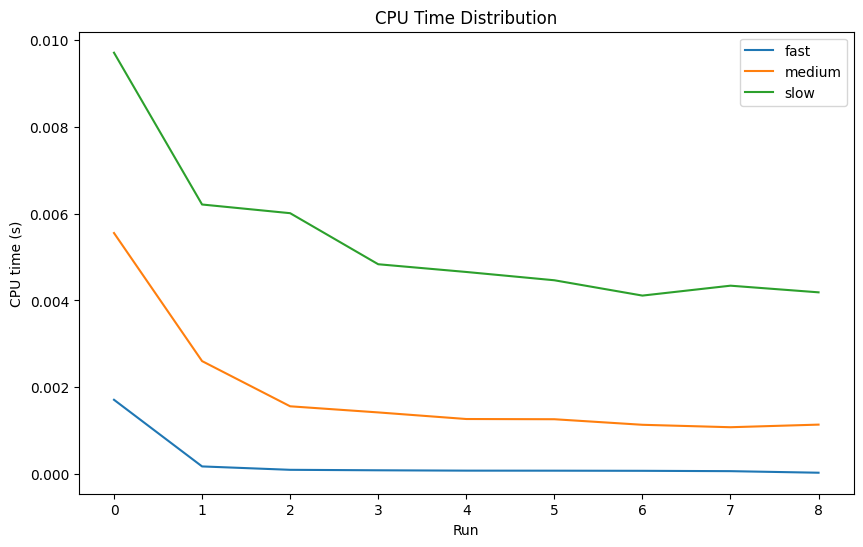

In [17]:
import matplotlib.pyplot as plt

times_fast = []
times_medium = []
times_slow = []

@profile(store=times_fast)
def fast_run():
    return f_fast()

@profile(store=times_medium)
def medium_run():
    return f_medium()

@profile(store=times_slow)
def slow_run():
    return f_slow()

# Collect a few samples
for _ in range(9):
    fast_run()
    medium_run()
    slow_run()

print("fast times:", times_fast)
print("medium times:", times_medium)
print("slow times:", times_slow)

x = np.arange(9)

plt.figure(figsize=(10, 6))
plt.plot(x, times_fast, label="fast")
plt.plot(x, times_medium, label="medium")
plt.plot(x, times_slow, label="slow")
plt.legend()
plt.xlabel("Run")
plt.ylabel("CPU time (s)")
plt.title("CPU Time Distribution")
plt.show()  

### Store CPU + Memory (rss/vms) into a dict

[PROFILE] __main__.f_fast() -> CPU Time 0.00009 s  | RSS: 201.70 MB | VMS: 402050.77 MB
[PROFILE] __main__.f_medium() -> CPU Time 0.00346 s  | RSS: 201.70 MB | VMS: 402050.77 MB
[PROFILE] __main__.f_slow() -> CPU Time 0.00850 s  | RSS: 205.45 MB | VMS: 402050.77 MB
[PROFILE] __main__.f_fast() -> CPU Time 0.00015 s  | RSS: 205.45 MB | VMS: 402050.77 MB
[PROFILE] __main__.f_medium() -> CPU Time 0.00182 s  | RSS: 205.45 MB | VMS: 402050.77 MB
[PROFILE] __main__.f_slow() -> CPU Time 0.00640 s  | RSS: 205.45 MB | VMS: 402050.77 MB
[PROFILE] __main__.f_fast() -> CPU Time 0.00014 s  | RSS: 205.45 MB | VMS: 402050.77 MB
[PROFILE] __main__.f_medium() -> CPU Time 0.00156 s  | RSS: 205.45 MB | VMS: 402050.77 MB
[PROFILE] __main__.f_slow() -> CPU Time 0.00518 s  | RSS: 205.45 MB | VMS: 402050.77 MB
[PROFILE] __main__.f_fast() -> CPU Time 0.00010 s  | RSS: 205.45 MB | VMS: 402050.77 MB
[PROFILE] __main__.f_medium() -> CPU Time 0.00151 s  | RSS: 205.45 MB | VMS: 402050.77 MB
[PROFILE] __main__.f_slo

/var/folders/tr/7wkvpsfn21zd7c6xmmpt7nfm0000gr/T/ipykernel_1746/1616926818.py:14: RuntimeWarning: divide by zero encountered in matmul
  return float((A @ B).sum())
/var/folders/tr/7wkvpsfn21zd7c6xmmpt7nfm0000gr/T/ipykernel_1746/1616926818.py:14: RuntimeWarning: overflow encountered in matmul
  return float((A @ B).sum())
/var/folders/tr/7wkvpsfn21zd7c6xmmpt7nfm0000gr/T/ipykernel_1746/1616926818.py:14: RuntimeWarning: invalid value encountered in matmul
  return float((A @ B).sum())
/var/folders/tr/7wkvpsfn21zd7c6xmmpt7nfm0000gr/T/ipykernel_1746/1616926818.py:20: RuntimeWarning: divide by zero encountered in matmul
  return float((A @ B).sum())
/var/folders/tr/7wkvpsfn21zd7c6xmmpt7nfm0000gr/T/ipykernel_1746/1616926818.py:20: RuntimeWarning: overflow encountered in matmul
  return float((A @ B).sum())
/var/folders/tr/7wkvpsfn21zd7c6xmmpt7nfm0000gr/T/ipykernel_1746/1616926818.py:20: RuntimeWarning: invalid value encountered in matmul
  return float((A @ B).sum())


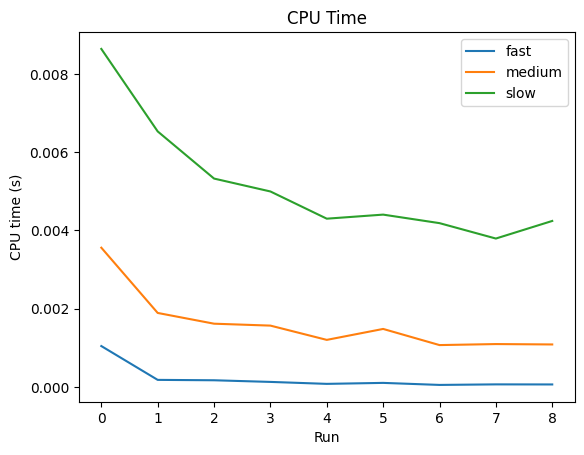

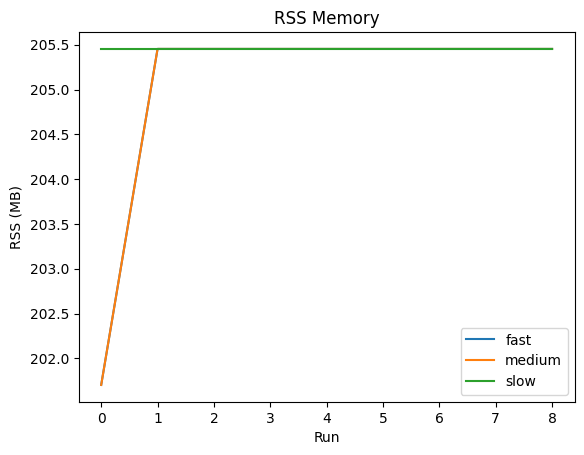

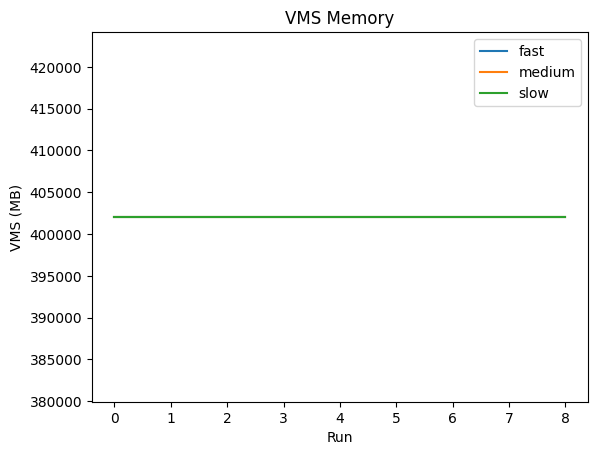

In [15]:
import matplotlib.pyplot as plt

log_fast  = {"cpu_time": [], "rss": [], "vms": []}
log_med   = {"cpu_time": [], "rss": [], "vms": []}
log_slow  = {"cpu_time": [], "rss": [], "vms": []}

@profile(store=log_fast)
def fast_run():
    return f_fast()

@profile(store=log_med)
def medium_run():
    return f_medium()

@profile(store=log_slow)
def slow_run():
    return f_slow()

# Run a few trials
for _ in range(9):
    fast_run()
    medium_run()
    slow_run()


x = np.arange(9)

plt.figure()
plt.plot(x, log_fast["cpu_time"], label="fast")
plt.plot(x, log_med["cpu_time"], label="medium")
plt.plot(x, log_slow["cpu_time"], label="slow")
plt.legend()
plt.xlabel("Run")
plt.ylabel("CPU time (s)")
plt.title("CPU Time")

plt.figure()
plt.plot(x, log_fast["rss"], label="fast")
plt.plot(x, log_med["rss"], label="medium")
plt.plot(x, log_slow["rss"], label="slow")
plt.legend()
plt.xlabel("Run")
plt.ylabel("RSS (MB)")
plt.title("RSS Memory")

plt.figure()
plt.plot(x, log_fast["vms"], label="fast")
plt.plot(x, log_med["vms"], label="medium")
plt.plot(x, log_slow["vms"], label="slow")
plt.legend()
plt.xlabel("Run")
plt.ylabel("VMS (MB)")
plt.title("VMS Memory")

plt.show()  